In [5]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, DataLoader
from glob import glob
import SimpleITK as sitk
from typing import Tuple, List, Dict, Optional, Callable
from lungmask import LMInferer
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
print(f'Versão do Torch: {torch.__version__}')
print(f'Versão do Torch: {torch.version.cuda}')

Versão do Torch: 2.4.0
Versão do Torch: 12.1


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

RAW_DATA_FOLDER = '/home/arthur/Documentos/transformers/data/atm22/'
PROCESSED_DATA_FOLDER = '/home/arthur/Documentos/generativas/dgm-2024.2/projetos/PulmoNet/data/processed'
inferer = LMInferer()

In [ ]:
def plot_img_label(img, label):
    f, axarr = plt.subplots(1,2)
    axarr[0].axis('off')
    axarr[1].axis('off')
    axarr[0].imshow(img, cmap='gray')
    axarr[1].imshow(label, cmap='gray')
    plt.show()

In [31]:
class rawCTData(Dataset):
    def __init__(self, mode: str, transform: Optional[Callable] = None):
        super().__init__()
        if mode == 'train':
            self.cts = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "imagesTr", "*.nii.gz")))
            self.labels = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "labelsTr", "*.nii.gz")))
        else:
            self.cts = sorted(glob(os.path.join(RAW_DATA_FOLDER, mode, "*.nii.gz")))
        self.transform = transform

    def __len__(self):
        return len(self.cts)
    
    def __getitem__(self, idx: int):
        '''
        Carregar, transformar e retornar o item 'i' do dataset
        Cada aquisição envolve 4 sequências presentes na dimensão de canais da imagem
        As sequências mapeam com a string RawMRIDataset.SEQUENCE
        '''
        ct_path = self.cts[idx]
        ct_labels_path = self.labels[idx]

        # Ler imagem usando a biblioteca SimpleITK, o objeto image contêm também metadados
        print(f'Reading {ct_path} and {ct_labels_path}.......')
        image = sitk.ReadImage(ct_path)
        label = sitk.ReadImage(ct_labels_path)

        # Converter imagem para array numpy na variável 'ct'
        print("Converting to array")
        ct = sitk.GetArrayFromImage(image)
        ct_label = sitk.GetArrayFromImage(label)
        ct_lung = inferer.apply(ct)
        ct_lung[ct_lung>1] = 1

        # Se uma função de transformada foi passada para o dataset, aplicá-la
        if self.transform is not None:
            ct = self.transform(ct)
        print(ct.shape)
        # Retornar a imagem e metadados
        return ct, ct_label, ct_lung

Reading /home/arthur/Documentos/transformers/data/atm22/train/imagesTr/ATM_001_0000.nii.gz and /home/arthur/Documentos/transformers/data/atm22/train/labelsTr/ATM_001_0000.nii.gz.......
Converting to array


 97%|█████████▋| 33/33.95 [00:08<00:00,  3.64it/s]/home/arthur/miniconda3/envs/torchenv/lib/python3.12/site-packages/tqdm/std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
100%|██████████| 34/33.95 [00:09<00:00,  3.69it/s]

lungmask 2024-09-24 14:55:24 Postprocessing



100%|██████████| 7/7 [00:00<00:00, 48.02it/s]


(679, 512, 512)


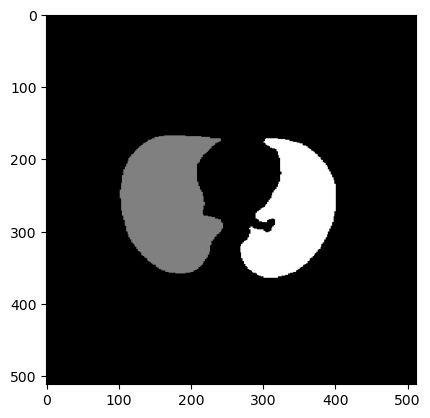

In [30]:
def test_lung_segmentator(data):
    for volume, _, lung in data:
        return lung

test_data = rawCTData('train') #, transform=MinMaxNormalize())
sample = test_lung_segmentator(test_data)
plt.imshow(sample[len(sample)//2], cmap = 'gray')

In [25]:
class MinMaxNormalize():
    '''
    Normaliza a imagem para o intervalo [0, 1]
    '''
    def __call__(self, x: np.ndarray) -> np.ndarray:
        return (x - x.min()) / (x.max() - x.min())

In [32]:
def preprocessing_for_lung():
    transform = MinMaxNormalize()
    file_number = 0
    for mode in ['train']: #, 'val']:
        if mode == 'train':
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode, 'imagesTr'), exist_ok=True)
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode, 'labelsTr'), exist_ok=True)
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode, 'lungsTr'), exist_ok=True)
        else:
            os.makedirs(os.path.join(PROCESSED_DATA_FOLDER, mode), exist_ok=True)
        raw_data = rawCTData(mode, transform=transform)

        for volume, _, lung in tqdm(raw_data):
            print(volume.shape, lung.shape)
            for ct_slice, ct_lung in zip(volume, lung):
                # Só estou processando fatias que tenham pulmão
                if np.sum(ct_lung) > 100:
                    img_filename = os.path.join(PROCESSED_DATA_FOLDER, mode, 'imagesTr', f"{file_number}.npz")
                    #label_filename = os.path.join(PROCESSED_DATA_FOLDER, mode, 'labelsTr',f"{file_number}.npz")
                    lung_filename = os.path.join(PROCESSED_DATA_FOLDER, mode, 'lungsTr',f"{file_number}.npz")
                    file_number += 1
                    np.savez_compressed(img_filename, ct_slice)
                    #np.savez_compressed(label_filename, ct_slice)
                    np.savez_compressed(lung_filename, ct_lung)

preprocessing_for_lung()

  0%|          | 0/299 [00:00<?, ?it/s]

Reading /home/arthur/Documentos/transformers/data/atm22/train/imagesTr/ATM_001_0000.nii.gz and /home/arthur/Documentos/transformers/data/atm22/train/labelsTr/ATM_001_0000.nii.gz.......
Converting to array



/home/arthur/miniconda3/envs/torchenv/lib/python3.12/site-packages/tqdm/std.py:636: TqdmWarning: clamping frac to range [0, 1]
100%|██████████| 34/33.95 [00:09<00:00,  3.63it/s]

lungmask 2024-09-24 15:01:16 Postprocessing



100%|██████████| 7/7 [00:00<00:00, 47.21it/s]


...

100%|██████████| 34/33.95 [00:08<00:00,  3.88it/s]

lungmask 2024-09-24 19:31:50 Postprocessing



100%|██████████| 3/3 [00:00<00:00, 57.96it/s]


(679, 512, 512)
(679, 512, 512) (679, 512, 512)


100%|██████████| 299/299 [4:31:24<00:00, 54.46s/it]


In [39]:
len(ct_path)

151022

In [48]:
ct_path = sorted(glob(os.path.join(PROCESSED_DATA_FOLDER, 'train', 'imagesTr', '*.npz')))
img = np.load(ct_path[random.randint(0, len(ct_path))])['arr_0']

In [49]:
img.shape

(512, 512)

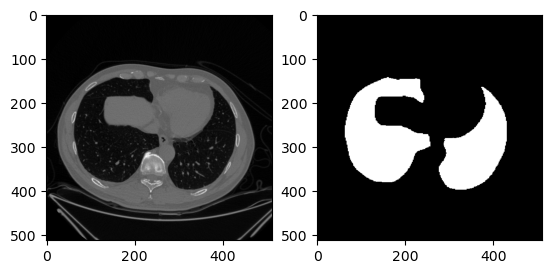

In [62]:
def test_processed_data():
    ct_path = sorted(glob(os.path.join(PROCESSED_DATA_FOLDER, 'train', 'imagesTr', '*.npz')))
    lung_path = sorted(glob(os.path.join(PROCESSED_DATA_FOLDER, 'train', 'lungsTr', '*.npz')))
    # confirmar quantidade de fatias
    assert len(ct_path) == len(lung_path)
    rnd_idx = random.randint(0, len(ct_path))
    ct_sample = np.load(ct_path[rnd_idx])['arr_0']
    lung_sample = np.load(lung_path[rnd_idx])['arr_0']
    assert ct_sample.shape == lung_sample.shape
    
    # comparação visual da ct e da segmentação
    f, axarr = plt.subplots(1,2)
    axarr[0].imshow(ct_sample, cmap='gray')
    axarr[1].imshow(lung_sample, cmap='gray')
    plt.show()

test_processed_data()

In [63]:
class lungCTData(Dataset):
    def __init__(self, mode: str, transform: Optional[Callable] = None):
        super().__init__()
        self.cts = sorted(glob(os.path.join(PROCESSED_DATA_FOLDER, mode, "imagesTr", "*.npz")))
        self.labels = sorted(glob(os.path.join(PROCESSED_DATA_FOLDER, mode, "lungsTr", "*.npz")))
        self.transform = transform
        assert len(self.cts) == len(self.labels)

    def __len__(self):
        return len(self.cts)
    
    def __getitem__(self, idx: int):
        '''
        Carregar, transformar e retornar o item 'i' do dataset
        Cada aquisição envolve 4 sequências presentes na dimensão de canais da imagem
        As sequências mapeam com a string RawMRIDataset.SEQUENCE
        '''
        ct_path = self.cts[idx]
        ct_labels_path = self.labels[idx]

        # Ler imagem usando a biblioteca SimpleITK, o objeto image contêm também metadados
        # print(f'Reading {ct_path} and {ct_labels_path}.......')
        image_npz = np.load(ct_path)
        lung_npz = np.load(ct_labels_path)

        ct = image_npz['arr_0']
        lung = lung_npz['arr_0']



        # Se uma função de transformada foi passada para o dataset, aplicá-la
        if self.transform is not None:
            ct = self.transform(ct)
        # Retornar a imagem e metadados
        return ct, lung

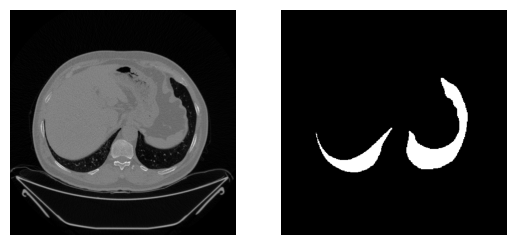

In [104]:
def test_lung_dataset():
    data = lungCTData('train')
    x,y = random.choice(data)
    assert x.shape == y.shape
    assert np.max(y) == 1
    assert np.max(x) <= 1
    assert np.min(x) >= 0

    plot_img_label(x,y)

test_lung_dataset()

In [ ]:
transforms = nn.Sequential(
    
)